In [1]:
data_dir = '/home/mjehangir/telomere-sv-analysis/data/'

In [2]:
setwd(data_dir)

In [3]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(scales)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [5]:
# Load the data from your txt file
file_path1 <- "./severus_somatic_sv_summary_rate_prop_pq.tsv"
sv_data <- read.table(file_path1, header = TRUE, sep = "\t")
file_path2 <- "./cnvs_summary_rate_prop_pq.tsv"
cnv_data <- read.table(file_path2, header = TRUE, sep = "\t")
file_path3 <- "/scratch/mjehangir/Glioma_project/glioma_aneuploidy/Glioma_v3_CNV_stats.txt"
aneu_data <- read.table(file_path3, header = TRUE, sep = "\t")
head(cnv_data)
head(sv_data)
head(aneu_data)


,ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,q,Gain,0.200152,1,124339061,124.33906,0.008042525,0.001609727,chr1q
2,2436A,chr10,q,Loss,17.220193,2,94108943,94.10894,0.021251965,0.182981473,chr10q
3,2436A,chr10,q,Loss,17.220193,2,94108943,94.10894,0.021251965,0.182981473,chr10q
4,2436A,chr15,q,Gain,1.602465,1,82566565,82.56656,0.012111440,0.019408159,chr15q
5,2436A,chr18,q,Loss,0.200356,1,62092914,62.09291,0.016104897,0.003226713,chr18q
6,2436A,chr19,q,Loss,7.012181,1,33914441,33.91444,0.029485964,0.206760919,chr19q


,filename,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,region
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,p,124048267,DEL,5,0.131346,124.0483,0.040306891,1.058830e-03,chr1p
2,2436A,chr1,p,124048267,DUP,4,0.034060,124.0483,0.032245513,2.745705e-04,chr1p
3,2436A,chr1,p,124048267,INS,2,0.004139,124.0483,0.016122756,3.336604e-05,chr1p
4,2436A,chr1,p,124048267,INV,1,0.000834,124.0483,0.008061378,6.723189e-06,chr1p
5,2436A,chr1,q,124339061,DEL,3,0.061028,124.3391,0.024127575,4.908192e-04,chr1q
6,2436A,chr1,q,124339061,DUP,2,0.027273,124.3391,0.016085050,2.193438e-04,chr1q


,SampleID,seqnames,arm,arm_call,arm_num_seg,arm_cr_wmean,arm_cr_wsd
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,6423A,chr21,21p,1,1,1.3206974,0.00000000
2,6436B,chr17,17p,0,1,0.9829569,0.00000000
3,6266D,chr17,17p,0,1,1.0289693,0.00000000
4,6265D,chr18,18p,0,1,0.9759641,0.00000000
5,6298B,chr17,17p,0,1,1.0329712,0.00000000
6,6500D,chr16,16p,0,2,0.9394281,0.02082144


NULL

`geom_smooth()` using formula = 'y ~ x'


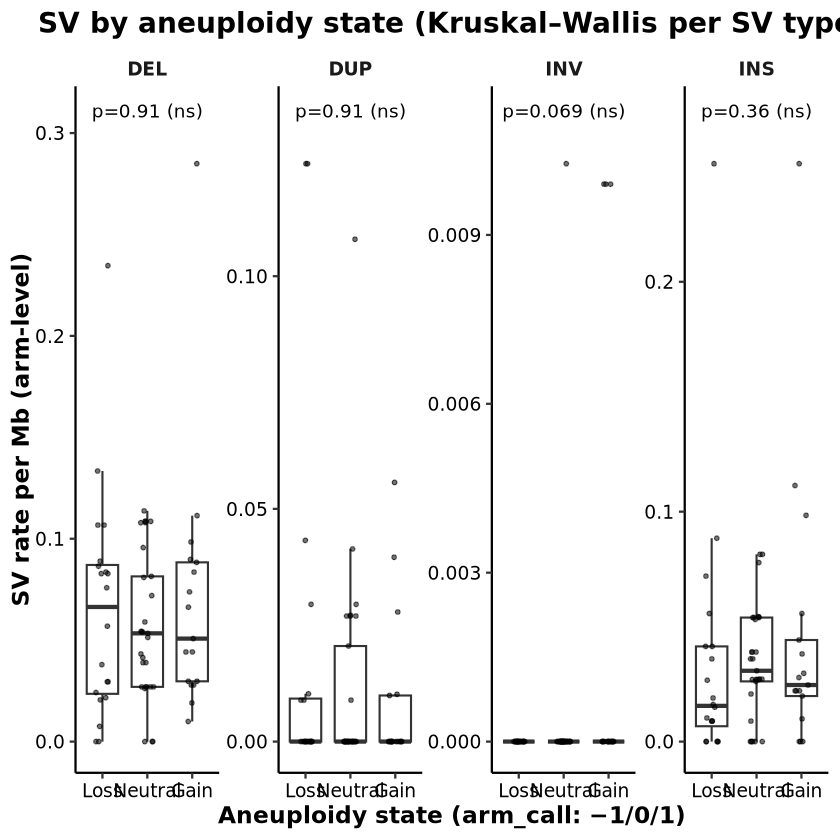

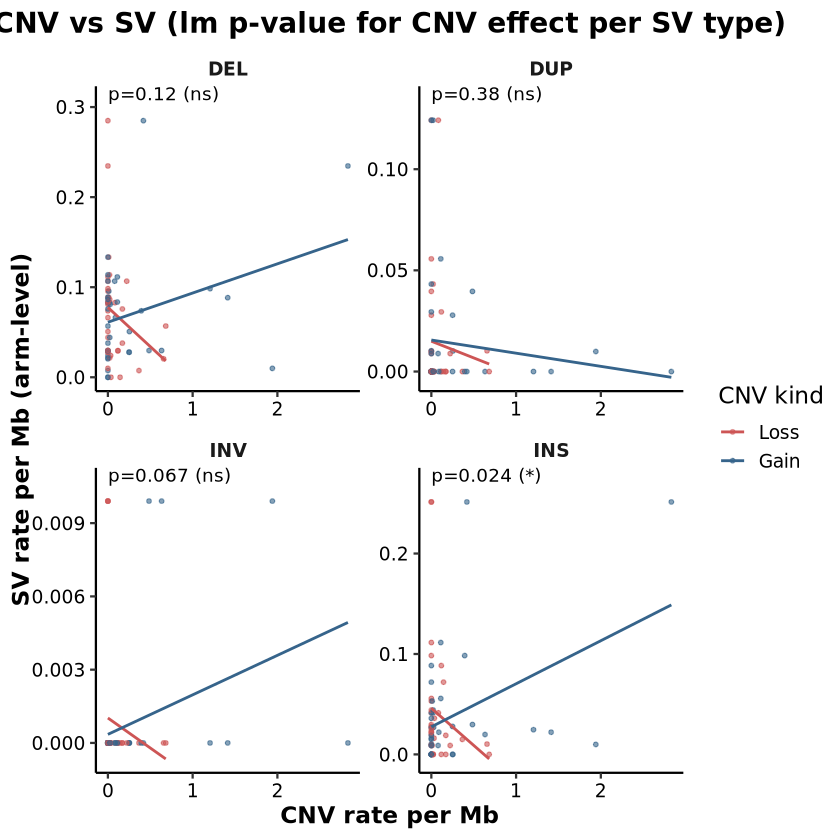

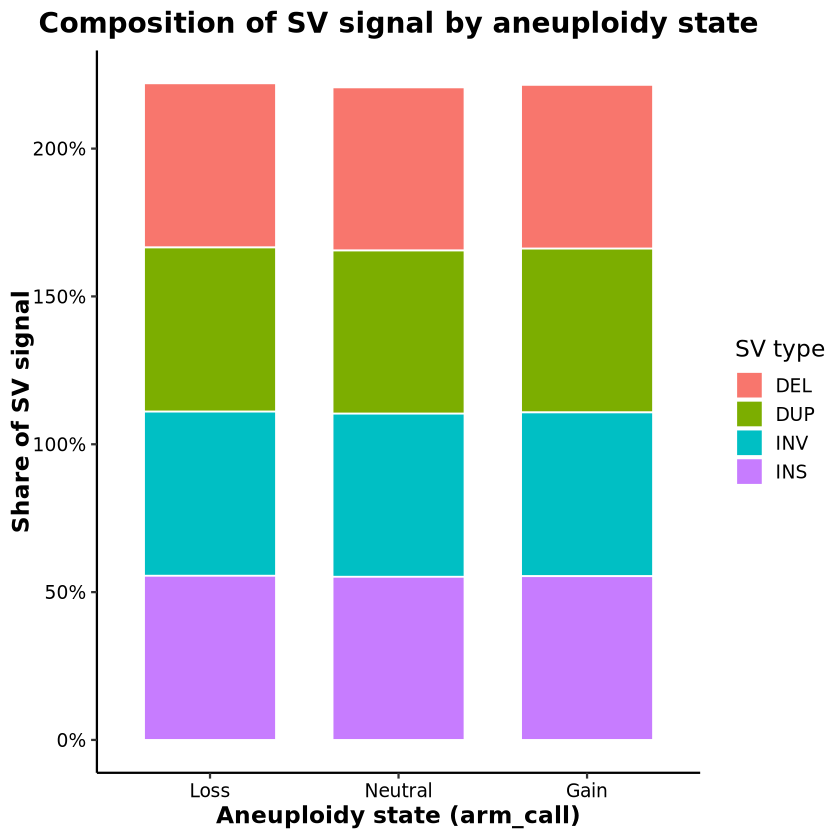

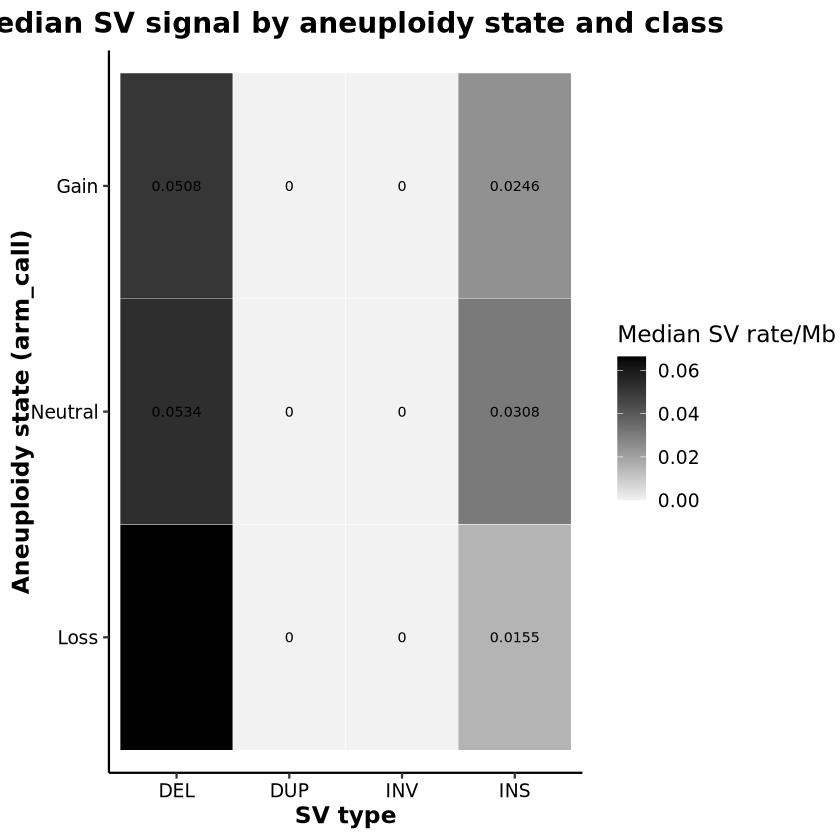

In [43]:
# ==========================================================
# Aneuploidy (arm_call) × SV types + CNV relations
# Publication-style figures; display-only (no saving)
# Inputs in memory: cnv_data, sv_data, aneu_data
# ==========================================================

suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(ggplot2); library(forcats); library(grid)
})

# ---------- helpers ----------
sanitize_names <- function(df) { names(df) <- gsub("\\.+", "_", names(df)); df }
pick_first_present <- function(df, candidates) { hit <- candidates[candidates %in% names(df)]; if (length(hit)) hit[1] else NULL }
std_sample_col <- function(df, candidates = c("Sample_ID","SampleID","ID","filename")) {
  col <- pick_first_present(df, candidates)
  if (is.null(col)) df$Sample_ID <- NA_character_ else if (col != "Sample_ID") df$Sample_ID <- df[[col]]
  df
}
only_pq <- function(x) { x <- tolower(x); y <- gsub("[^pq]", "", x); y[y==""] <- NA_character_; y }

# Vectorized p-formatters
p_stars_vec <- function(p) {
  out <- rep("ns", length(p))
  out[!is.na(p) & p < 0.05]  <- "*"
  out[!is.na(p) & p < 1e-2]  <- "**"
  out[!is.na(p) & p < 1e-3]  <- "***"
  out[!is.na(p) & p < 1e-4]  <- "****"
  out
}
fmt_p_vec <- function(p) {
  out <- rep("p=NA", length(p))
  out[!is.na(p) & p >= 1e-3] <- paste0("p=", signif(p[!is.na(p) & p >= 1e-3], 2))
  out[!is.na(p) & p <  1e-3] <- paste0("p=", formatC(p[!is.na(p) & p < 1e-3], format="e", digits=2))
  out
}
theme_ng <- function(base_size = 14) {
  theme_classic(base_size = base_size) +
    theme(
      axis.title = element_text(face="bold"),
      axis.text  = element_text(color="black"),
      strip.background = element_blank(),
      strip.text = element_text(face="bold"),
      panel.spacing = unit(8, "pt"),
      plot.title = element_text(hjust=0.5, face="bold")
    )
}

# ---------- CNV (rate/proportion per arm & Gain/Loss) ----------
cnv_tmp <- cnv_data %>% sanitize_names() %>% std_sample_col()
if ("arm" %in% names(cnv_tmp)) {
  cnv_tmp$region <- cnv_tmp$arm
} else if (all(c("chrom","Arm") %in% names(cnv_tmp))) {
  cnv_tmp$region <- paste0(cnv_tmp$chrom, cnv_tmp$Arm)
} else {
  cnv_tmp$region <- NA_character_
}

cnv_tmp <- cnv_tmp %>%
  mutate(
    total_cnv_length = suppressWarnings(as.numeric(total_cnv_length)),
    segment_count    = suppressWarnings(as.integer(segment_count)),
    arm_length_mb    = suppressWarnings(as.numeric(arm_length_mb)),
    Length           = suppressWarnings(as.numeric(Length))
  ) %>%
  filter(!is.na(Sample_ID), !is.na(region), region != "")

if (all(is.na(cnv_tmp$arm_length_mb)) && any(is.finite(cnv_tmp$Length))) {
  cnv_tmp <- cnv_tmp %>% mutate(arm_length_mb = Length / 1e6)
}

cnv_wide <- cnv_tmp %>%
  mutate(Gain_Loss = dplyr::coalesce(Gain_Loss, get0("gain_loss", ifnotfound = NA_character_))) %>%
  group_by(Sample_ID, region, Gain_Loss) %>%
  summarise(
    total_cnv_length = sum(total_cnv_length, na.rm = TRUE),
    segment_count    = sum(segment_count,    na.rm = TRUE),
    arm_length_mb    = {x <- na.omit(arm_length_mb); if (length(x)) x[1] else NA_real_},
    .groups = "drop"
  ) %>%
  mutate(
    cnv_rate_per_mb       = ifelse(is.finite(segment_count/arm_length_mb), segment_count/arm_length_mb, NA_real_),
    cnv_proportion_per_mb = ifelse(is.finite(total_cnv_length/arm_length_mb), total_cnv_length/arm_length_mb, NA_real_),
    Gain_Loss = case_when(
      tolower(Gain_Loss) %in% c("gain","g","amp") ~ "Gain",
      tolower(Gain_Loss) %in% c("loss","l","del") ~ "Loss",
      TRUE ~ as.character(Gain_Loss)
    )
  ) %>%
  tidyr::pivot_wider(
    names_from = Gain_Loss,
    values_from = c(cnv_rate_per_mb, cnv_proportion_per_mb),
    values_fill = 0
  )

# ---------- SV (by type per arm) ----------
sv_tmp <- sv_data %>% sanitize_names() %>% std_sample_col()
if ("region" %in% names(sv_tmp) && any(nzchar(sv_tmp$region))) {
  # keep
} else if (all(c("chr","Arm") %in% names(sv_tmp))) {
  sv_tmp$region <- paste0(sv_tmp$chr, sv_tmp$Arm)
} else {
  sv_tmp$region <- NA_character_
}

sv_tmp <- sv_tmp %>%
  mutate(
    type          = toupper(type),
    sv_count      = suppressWarnings(as.numeric(sv_count)),
    sv_rate       = suppressWarnings(as.numeric(sv_rate)),
    sv_proportion = suppressWarnings(as.numeric(sv_proportion))
  ) %>%
  filter(!is.na(Sample_ID), !is.na(region), region != "")

sv_types <- intersect(c("DEL","DUP","INV","INS"), unique(sv_tmp$type))
sv_wide <- sv_tmp %>%
  filter(type %in% sv_types) %>%
  group_by(Sample_ID, region, type) %>%
  summarise(
    sv_count      = sum(sv_count,      na.rm = TRUE),
    sv_rate       = sum(sv_rate,       na.rm = TRUE),
    sv_proportion = sum(sv_proportion, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  tidyr::pivot_wider(
    names_from = type,
    values_from = c(sv_count, sv_rate, sv_proportion),
    values_fill = 0
  )

# ---------- Aneuploidy from arm_call (−1,0,1) ----------
aneu_tmp <- aneu_data %>% sanitize_names() %>% std_sample_col() %>%
  mutate(
    arm_letter = only_pq(arm),
    region     = ifelse(!is.na(seqnames) & !is.na(arm_letter), paste0(seqnames, arm_letter), NA_character_),
    arm_call   = suppressWarnings(as.integer(arm_call)),
    aneu_state = case_when(
      arm_call == -1 ~ "Loss",
      arm_call ==  0 ~ "Neutral",
      arm_call ==  1 ~ "Gain",
      TRUE ~ NA_character_
    ),
    aneu_state = factor(aneu_state, levels = c("Loss","Neutral","Gain"))
  ) %>%
  filter(!is.na(Sample_ID), !is.na(region), region != "", !is.na(aneu_state)) %>%
  select(Sample_ID, region, aneu_state)

# ---------- Merge ----------
arm_level <- aneu_tmp %>%
  left_join(cnv_wide, by = c("Sample_ID","region")) %>%
  left_join(sv_wide,  by = c("Sample_ID","region")) %>%
  filter(str_detect(region, "^chr[0-9XY]+[pq]$"))

# Choose SV metric (prefer rate → count → proportion)
sv_prefix <- if (any(grepl("^sv_rate_", names(arm_level)))) "sv_rate" else
             if (any(grepl("^sv_count_", names(arm_level)))) "sv_count" else
             if (any(grepl("^sv_proportion_", names(arm_level)))) "sv_proportion" else NULL
stopifnot(!is.null(sv_prefix))

# Choose CNV metric (prefer rate → proportion)
cnv_metric <- if (any(grepl("^cnv_rate_per_mb_", names(arm_level)))) "cnv_rate_per_mb" else
              if (any(grepl("^cnv_proportion_per_mb_", names(arm_level)))) "cnv_proportion_per_mb" else NULL
stopifnot(!is.null(cnv_metric))

# ==========================================================
# PLOT 1 — SV vs Aneuploidy state (from arm_call) with KW p
# ==========================================================
sv_long <- arm_level %>%
  select(Sample_ID, region, aneu_state,
         matches(paste0("^", sv_prefix, "_(DEL|DUP|INV|INS)$"))) %>%
  pivot_longer(cols = matches(paste0("^", sv_prefix, "_")),
               names_to = "sv_type", values_to = "sv_value") %>%
  mutate(type = factor(sub(paste0("^", sv_prefix, "_"), "", sv_type),
                       levels = c("DEL","DUP","INV","INS")))

kw_df <- sv_long %>%
  filter(is.finite(sv_value), !is.na(aneu_state)) %>%
  group_by(type) %>%
  summarise(
    p_kw  = tryCatch({
      if (length(unique(aneu_state)) >= 2 && sum(is.finite(sv_value)) >= 3)
        kruskal.test(sv_value ~ aneu_state)$p.value else NA_real_
    }, error = function(e) NA_real_),
    y_pos = suppressWarnings(max(sv_value, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(
    y_pos = ifelse(is.finite(y_pos), y_pos, 0) * 1.08,
    x_pos = 2,
    label = paste0(fmt_p_vec(p_kw), " (", p_stars_vec(p_kw), ")")
  )

set.seed(1)
p1 <- sv_long %>%
  filter(!is.na(aneu_state), is.finite(sv_value)) %>%
  ggplot(aes(x = aneu_state, y = sv_value)) +
  geom_boxplot(outlier.shape = NA, width = 0.7, linewidth = 0.6) +
  geom_point(position = position_jitter(width = 0.15, height = 0),
             alpha = 0.55, size = 1) +
  facet_wrap(~ type, scales = "free_y", nrow = 1) +
  geom_text(data = kw_df, aes(x = x_pos, y = y_pos, label = label),
            inherit.aes = FALSE, hjust = 0.5, vjust = 0) +
  labs(
    x = "Aneuploidy state (arm_call: −1/0/1)",
    y = paste(switch(sv_prefix,
                     sv_rate = "SV rate per Mb",
                     sv_count = "SV count",
                     sv_proportion = "SV proportion"), "(arm-level)"),
    title = "SV by aneuploidy state (Kruskal–Wallis per SV type)"
  ) +
  theme_ng(14)
print(p1)

# ==========================================================
# PLOT 2 — CNV vs SV (faceted by SV type; color=Gain/Loss)
#  (LM p-value for CNV effect per SV type)
# ==========================================================
cnv_sv_long <- arm_level %>%
  select(Sample_ID, region, aneu_state,
         matches(paste0("^", cnv_metric, "_(Gain|Loss)$")),
         matches(paste0("^", sv_prefix, "_(DEL|DUP|INV|INS)$"))) %>%
  pivot_longer(cols = matches(paste0("^", sv_prefix, "_")),
               names_to = "sv_type", values_to = "sv_value") %>%
  mutate(type = factor(sub(paste0("^", sv_prefix, "_"), "", sv_type),
                       levels = c("DEL","DUP","INV","INS"))) %>%
  pivot_longer(cols = matches(paste0("^", cnv_metric, "_(Gain|Loss)$")),
               names_to = "cnv_kind", values_to = "cnv_value") %>%
  mutate(cnv_kind = ifelse(grepl("Gain$", cnv_kind), "Gain", "Loss"),
         cnv_kind = factor(cnv_kind, levels = c("Loss","Gain")))

lm_df <- cnv_sv_long %>%
  filter(is.finite(cnv_value), is.finite(sv_value)) %>%
  group_by(type) %>%
  summarise(
    p_lm = tryCatch({
      fit <- lm(sv_value ~ cnv_value + cnv_kind)
      co <- summary(fit)$coefficients
      if ("cnv_value" %in% rownames(co)) co["cnv_value","Pr(>|t|)"] else NA_real_
    }, error = function(e) NA_real_),
    x_pos = suppressWarnings(min(cnv_value, na.rm = TRUE)),
    y_pos = suppressWarnings(max(sv_value,  na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(
    x_pos = ifelse(is.finite(x_pos), x_pos, 0),
    y_pos = ifelse(is.finite(y_pos), y_pos, 0) * 1.08,
    label = paste0(fmt_p_vec(p_lm), " (", p_stars_vec(p_lm), ")")
  )

p2 <- cnv_sv_long %>%
  filter(is.finite(cnv_value), is.finite(sv_value)) %>%
  ggplot(aes(x = cnv_value, y = sv_value, color = cnv_kind)) +
  geom_point(alpha = 0.6, size = 1) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  facet_wrap(~ type, scales = "free") +
  geom_text(data = lm_df, aes(x = x_pos, y = y_pos, label = label),
            inherit.aes = FALSE, hjust = 0, vjust = 0) +
  scale_color_manual(values = c("Loss" = "indianred3", "Gain" = "steelblue4")) +
  labs(
    x = if (cnv_metric == "cnv_rate_per_mb") "CNV rate per Mb" else "CNV proportion per Mb",
    y = paste(switch(sv_prefix,
                     sv_rate = "SV rate per Mb",
                     sv_count = "SV count",
                     sv_proportion = "SV proportion"), "(arm-level)"),
    color = "CNV kind",
    title = "CNV vs SV (lm p-value for CNV effect per SV type)"
  ) +
  theme_ng(14)
print(p2)

# ==========================================================
# ALT VIEW A — Stacked proportions of SV classes by arm_call state
#   (What fraction of total SV signal per state comes from each type?)
# ==========================================================
agg_metric <- if (sv_prefix == "sv_count") "sv_count" else if (sv_prefix == "sv_rate") "sv_rate" else "sv_proportion"

sv_state_sum <- arm_level %>%
  select(aneu_state, matches(paste0("^", agg_metric, "_(DEL|DUP|INV|INS)$"))) %>%
  pivot_longer(cols = matches(paste0("^", agg_metric, "_")),
               names_to = "sv_type", values_to = "value") %>%
  mutate(type = factor(sub(paste0("^", agg_metric, "_"), "", sv_type),
                       levels = c("DEL","DUP","INV","INS"))) %>%
  group_by(aneu_state, type) %>%
  summarise(total = sum(value, na.rm = TRUE), .groups = "drop") %>%
  group_by(aneu_state) %>%
  mutate(frac = ifelse(sum(total) > 0, total / sum(total), 0)) %>%
  ungroup()

p3 <- ggplot(sv_state_sum, aes(x = aneu_state, y = frac, fill = type)) +
  geom_bar(stat = "identity", width = 0.7, color = "white") +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    x = "Aneuploidy state (arm_call)",
    y = "Share of SV signal",
    fill = "SV type",
    title = "Composition of SV signal by aneuploidy state"
  ) +
  theme_ng(14)
print(p3)

# ==========================================================
# ALT VIEW B — Tile heatmap of median SV metric by state×type
# ==========================================================
sv_state_median <- arm_level %>%
  select(aneu_state, matches(paste0("^", agg_metric, "_(DEL|DUP|INV|INS)$"))) %>%
  pivot_longer(cols = matches(paste0("^", agg_metric, "_")),
               names_to = "sv_type", values_to = "value") %>%
  mutate(type = factor(sub(paste0("^", agg_metric, "_"), "", sv_type),
                       levels = c("DEL","DUP","INV","INS"))) %>%
  group_by(aneu_state, type) %>%
  summarise(median_val = median(value, na.rm = TRUE), .groups = "drop")

p4 <- ggplot(sv_state_median, aes(x = type, y = aneu_state, fill = median_val)) +
  geom_tile(color = "white") +
  geom_text(aes(label = signif(median_val, 3)), size = 3) +
  scale_fill_gradient(name = paste("Median", switch(agg_metric,
                                                    sv_rate="SV rate/Mb",
                                                    sv_count="SV count",
                                                    sv_proportion="SV proportion")),
                      low = "grey95", high = "black") +
  labs(
    x = "SV type",
    y = "Aneuploidy state (arm_call)",
    title = "Median SV signal by aneuploidy state and class"
  ) +
  theme_ng(14)
print(p4)


NULL

`geom_smooth()` using formula = 'y ~ x'


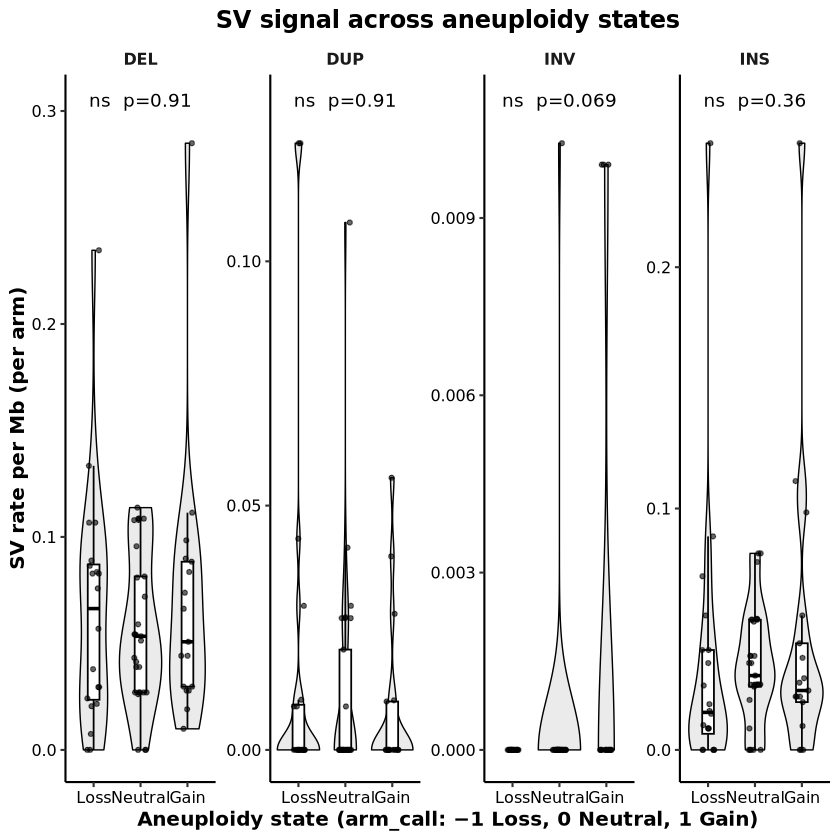

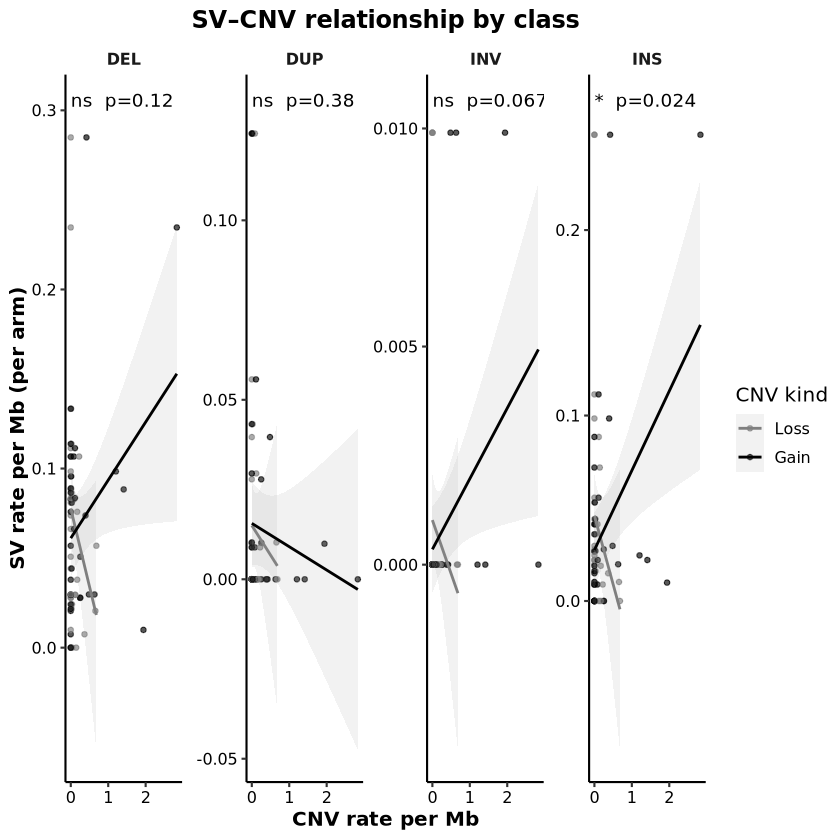

In [44]:
# ==========================================================
# Two Nature-style plots using arm_call (−1/0/1) vs SV types
#  • Plot 1: SV signal ~ aneuploidy state (KW p per type)
#  • Plot 2: CNV (Gain/Loss) vs SV signal (slope p per type)
# Inputs already in memory: aneu_data, sv_data, cnv_data
# Display only; no files saved.
# ==========================================================

suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(ggplot2); library(forcats); library(grid)
})

# ---------- helpers ----------
sanitize_names <- function(df) { names(df) <- gsub("\\.+", "_", names(df)); df }
pick_first_present <- function(df, candidates) {
  hits <- candidates[candidates %in% names(df)]
  if (length(hits)) hits[1] else NULL
}
std_sample_col <- function(df, candidates = c("Sample_ID","SampleID","ID","filename")) {
  col <- pick_first_present(df, candidates)
  if (is.null(col)) { df$Sample_ID <- NA_character_ }
  else if (col != "Sample_ID") { df$Sample_ID <- df[[col]] }
  df
}
only_pq <- function(x) { x <- tolower(x); y <- gsub("[^pq]", "", x); y[y==""] <- NA_character_; y }

# Vectorized p formatters (always returns a label; "ns" if NA or ≥0.05)
p_stars_vec <- function(p) {
  out <- rep("ns", length(p))
  out[!is.na(p) & p < 0.05]  <- "*"
  out[!is.na(p) & p < 1e-2]  <- "**"
  out[!is.na(p) & p < 1e-3]  <- "***"
  out[!is.na(p) & p < 1e-4]  <- "****"
  out
}
fmt_p_vec <- function(p) {
  out <- rep("p=NA", length(p))
  ok <- !is.na(p)
  out[ok & p >= 1e-3] <- paste0("p=", signif(p[ok & p >= 1e-3], 2))
  out[ok & p <  1e-3] <- paste0("p=", formatC(p[ok & p < 1e-3], format="e", digits=2))
  out
}

theme_nature <- function(base_size = 12) {
  theme_classic(base_size = base_size) +
    theme(
      axis.title  = element_text(face = "bold"),
      axis.text   = element_text(color = "black"),
      axis.line   = element_line(linewidth = 0.6),
      axis.ticks  = element_line(linewidth = 0.6),
      strip.background = element_blank(),
      strip.text  = element_text(face = "bold"),
      panel.spacing = unit(8, "pt"),
      plot.title  = element_text(hjust = 0.5, face = "bold")
    )
}

# ---------- Build CNV arm-level metrics ----------
cnv_tmp <- cnv_data %>% sanitize_names() %>% std_sample_col()
if ("arm" %in% names(cnv_tmp)) {
  cnv_tmp$region <- cnv_tmp$arm
} else if (all(c("chrom","Arm") %in% names(cnv_tmp))) {
  cnv_tmp$region <- paste0(cnv_tmp$chrom, cnv_tmp$Arm)
} else {
  cnv_tmp$region <- NA_character_
}

cnv_tmp <- cnv_tmp %>%
  mutate(
    total_cnv_length = suppressWarnings(as.numeric(total_cnv_length)),
    segment_count    = suppressWarnings(as.integer(segment_count)),
    arm_length_mb    = suppressWarnings(as.numeric(arm_length_mb)),
    Length           = suppressWarnings(as.numeric(Length))
  ) %>%
  filter(!is.na(Sample_ID), !is.na(region), region != "")

# if arm_length_mb missing but Length present (bp), infer
if (all(is.na(cnv_tmp$arm_length_mb)) && any(is.finite(cnv_tmp$Length))) {
  cnv_tmp <- cnv_tmp %>% mutate(arm_length_mb = Length / 1e6)
}

cnv_wide <- cnv_tmp %>%
  mutate(Gain_Loss = dplyr::coalesce(Gain_Loss, get0("gain_loss", ifnotfound = NA_character_))) %>%
  group_by(Sample_ID, region, Gain_Loss) %>%
  summarise(
    total_cnv_length = sum(total_cnv_length, na.rm = TRUE),
    segment_count    = sum(segment_count,    na.rm = TRUE),
    arm_length_mb    = {x <- na.omit(arm_length_mb); if (length(x)) x[1] else NA_real_},
    .groups = "drop"
  ) %>%
  mutate(
    cnv_rate_per_mb       = ifelse(is.finite(segment_count/arm_length_mb), segment_count/arm_length_mb, NA_real_),
    cnv_proportion_per_mb = ifelse(is.finite(total_cnv_length/arm_length_mb), total_cnv_length/arm_length_mb, NA_real_),
    Gain_Loss = case_when(
      tolower(Gain_Loss) %in% c("gain","g","amp") ~ "Gain",
      tolower(Gain_Loss) %in% c("loss","l","del") ~ "Loss",
      TRUE ~ as.character(Gain_Loss)
    )
  ) %>%
  tidyr::pivot_wider(
    names_from = Gain_Loss,
    values_from = c(cnv_rate_per_mb, cnv_proportion_per_mb),
    values_fill = 0
  )

# ---------- Build SV arm-level metrics ----------
sv_tmp <- sv_data %>% sanitize_names() %>% std_sample_col()
if ("region" %in% names(sv_tmp) && any(nzchar(sv_tmp$region))) {
  # use existing
} else if (all(c("chr","Arm") %in% names(sv_tmp))) {
  sv_tmp$region <- paste0(sv_tmp$chr, sv_tmp$Arm)
} else {
  sv_tmp$region <- NA_character_
}

sv_tmp <- sv_tmp %>%
  mutate(
    type          = toupper(type),
    sv_count      = suppressWarnings(as.numeric(sv_count)),
    sv_rate       = suppressWarnings(as.numeric(sv_rate)),
    sv_proportion = suppressWarnings(as.numeric(sv_proportion))
  ) %>%
  filter(!is.na(Sample_ID), !is.na(region), region != "")

sv_types <- intersect(c("DEL","DUP","INV","INS"), unique(sv_tmp$type))
sv_wide <- sv_tmp %>%
  filter(type %in% sv_types) %>%
  group_by(Sample_ID, region, type) %>%
  summarise(
    sv_count      = sum(sv_count,      na.rm = TRUE),
    sv_rate       = sum(sv_rate,       na.rm = TRUE),
    sv_proportion = sum(sv_proportion, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  tidyr::pivot_wider(
    names_from = type,
    values_from = c(sv_count, sv_rate, sv_proportion),
    values_fill = 0
  )

# ---------- Aneuploidy states from arm_call (−1/0/1) ----------
aneu_tmp <- aneu_data %>% sanitize_names() %>% std_sample_col() %>%
  mutate(
    arm_letter = only_pq(arm),
    region     = ifelse(!is.na(seqnames) & !is.na(arm_letter), paste0(seqnames, arm_letter), NA_character_),
    arm_call   = suppressWarnings(as.integer(arm_call)),
    aneu_state = case_when(
      arm_call == -1 ~ "Loss",
      arm_call ==  0 ~ "Neutral",
      arm_call ==  1 ~ "Gain",
      TRUE ~ NA_character_
    ),
    aneu_state = factor(aneu_state, levels = c("Loss","Neutral","Gain"))
  ) %>%
  filter(!is.na(Sample_ID), !is.na(region), region != "", !is.na(aneu_state)) %>%
  select(Sample_ID, region, aneu_state)

# ---------- Merge everything ----------
arm_level <- aneu_tmp %>%
  left_join(cnv_wide, by = c("Sample_ID","region")) %>%
  left_join(sv_wide,  by = c("Sample_ID","region")) %>%
  filter(str_detect(region, "^chr[0-9XY]+[pq]$"))

# choose SV metric (prefer rate → count → proportion)
sv_prefix <- if (any(grepl("^sv_rate_", names(arm_level)))) "sv_rate" else
             if (any(grepl("^sv_count_", names(arm_level)))) "sv_count" else
             if (any(grepl("^sv_proportion_", names(arm_level)))) "sv_proportion" else NULL
stopifnot(!is.null(sv_prefix))

# choose CNV metric (prefer rate → proportion)
cnv_metric <- if (any(grepl("^cnv_rate_per_mb_", names(arm_level)))) "cnv_rate_per_mb" else
              if (any(grepl("^cnv_proportion_per_mb_", names(arm_level)))) "cnv_proportion_per_mb" else NULL
stopifnot(!is.null(cnv_metric))

# ==========================================================
# PLOT 1 — SV signal vs aneuploidy state (arm_call)
#  - Facets: SV type (DEL/DUP/INV/INS)
#  - Stats: Kruskal–Wallis p per facet (label shows stars + p)
# ==========================================================
sv_long <- arm_level %>%
  select(Sample_ID, region, aneu_state,
         dplyr::matches(paste0("^", sv_prefix, "_(DEL|DUP|INV|INS)$"))) %>%
  pivot_longer(cols = dplyr::matches(paste0("^", sv_prefix, "_")),
               names_to = "sv_type", values_to = "sv_value") %>%
  mutate(type = factor(sub(paste0("^", sv_prefix, "_"), "", sv_type),
                       levels = c("DEL","DUP","INV","INS")))

# KW p per type
kw_df <- sv_long %>%
  filter(is.finite(sv_value), !is.na(aneu_state)) %>%
  group_by(type) %>%
  summarise(
    p_kw = tryCatch({
      if (length(unique(aneu_state)) >= 2 && sum(is.finite(sv_value)) >= 3)
        kruskal.test(sv_value ~ aneu_state)$p.value else NA_real_
    }, error = function(e) NA_real_),
    y_pos = suppressWarnings(max(sv_value, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(
    y_pos = ifelse(is.finite(y_pos), y_pos, 0) * 1.06,
    x_pos = 2,
    label = paste0(p_stars_vec(p_kw), "  ", fmt_p_vec(p_kw))
  )

set.seed(1)
p1 <- sv_long %>%
  filter(!is.na(aneu_state), is.finite(sv_value)) %>%
  ggplot(aes(x = aneu_state, y = sv_value)) +
  # minimalist "Nature" look: light violin, thin box, black points
  geom_violin(fill = "grey92", color = "black", linewidth = 0.4, width = 0.9, trim = TRUE) +
  geom_boxplot(width = 0.25, outlier.shape = NA, fill = "white", color = "black", linewidth = 0.5) +
  geom_point(position = position_jitter(width = 0.14, height = 0),
             size = 1.1, alpha = 0.6) +
  facet_wrap(~ type, nrow = 1, scales = "free_y") +
  geom_text(data = kw_df, aes(x = x_pos, y = y_pos, label = label),
            inherit.aes = FALSE, hjust = 0.5, vjust = 0) +
  labs(
    x = "Aneuploidy state (arm_call: −1 Loss, 0 Neutral, 1 Gain)",
    y = paste(switch(sv_prefix,
                     sv_rate = "SV rate per Mb",
                     sv_count = "SV count",
                     sv_proportion = "SV proportion"), "(per arm)"),
    title = "SV signal across aneuploidy states"
  ) +
  theme_nature(12)
print(p1)

# ==========================================================
# PLOT 2 — CNV (Gain/Loss) vs SV signal
#  - Facets: SV type; Color: CNV kind (Gain/Loss)
#  - Stats: slope p for CNV effect per facet (label shows stars + p)
# ==========================================================
cnv_sv_long <- arm_level %>%
  select(Sample_ID, region,
         dplyr::matches(paste0("^", cnv_metric, "_(Gain|Loss)$")),
         dplyr::matches(paste0("^", sv_prefix, "_(DEL|DUP|INV|INS)$"))) %>%
  pivot_longer(cols = dplyr::matches(paste0("^", sv_prefix, "_")),
               names_to = "sv_type", values_to = "sv_value") %>%
  mutate(type = factor(sub(paste0("^", sv_prefix, "_"), "", sv_type),
                       levels = c("DEL","DUP","INV","INS"))) %>%
  pivot_longer(cols = dplyr::matches(paste0("^", cnv_metric, "_(Gain|Loss)$")),
               names_to = "cnv_kind", values_to = "cnv_value") %>%
  mutate(cnv_kind = ifelse(grepl("Gain$", cnv_kind), "Gain", "Loss"),
         cnv_kind = factor(cnv_kind, levels = c("Loss","Gain")))

# slope p per type
lm_df <- cnv_sv_long %>%
  filter(is.finite(cnv_value), is.finite(sv_value)) %>%
  group_by(type) %>%
  summarise(
    p_lm = tryCatch({
      fit <- lm(sv_value ~ cnv_value + cnv_kind)
      co <- summary(fit)$coefficients
      if ("cnv_value" %in% rownames(co)) co["cnv_value","Pr(>|t|)"] else NA_real_
    }, error = function(e) NA_real_),
    x_pos = suppressWarnings(min(cnv_value, na.rm = TRUE)),
    y_pos = suppressWarnings(max(sv_value,  na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(
    x_pos = ifelse(is.finite(x_pos), x_pos, 0),
    y_pos = ifelse(is.finite(y_pos), y_pos, 0) * 1.06,
    label = paste0(p_stars_vec(p_lm), "  ", fmt_p_vec(p_lm))
  )

p2 <- cnv_sv_long %>%
  filter(is.finite(cnv_value), is.finite(sv_value)) %>%
  ggplot(aes(x = cnv_value, y = sv_value, color = cnv_kind)) +
  geom_point(size = 1.2, alpha = 0.65) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 0.8, alpha = 0.12) +
  facet_wrap(~ type, nrow = 1, scales = "free") +
  scale_color_manual(values = c("Loss" = "#7F7F7F", "Gain" = "black")) +
  geom_text(data = lm_df, aes(x = x_pos, y = y_pos, label = label),
            inherit.aes = FALSE, hjust = 0, vjust = 0) +
  labs(
    x = if (cnv_metric == "cnv_rate_per_mb") "CNV rate per Mb" else "CNV proportion per Mb",
    y = paste(switch(sv_prefix,
                     sv_rate = "SV rate per Mb",
                     sv_count = "SV count",
                     sv_proportion = "SV proportion"), "(per arm)"),
    color = "CNV kind",
    title = "SV–CNV relationship by class"
  ) +
  theme_nature(12)
print(p2)





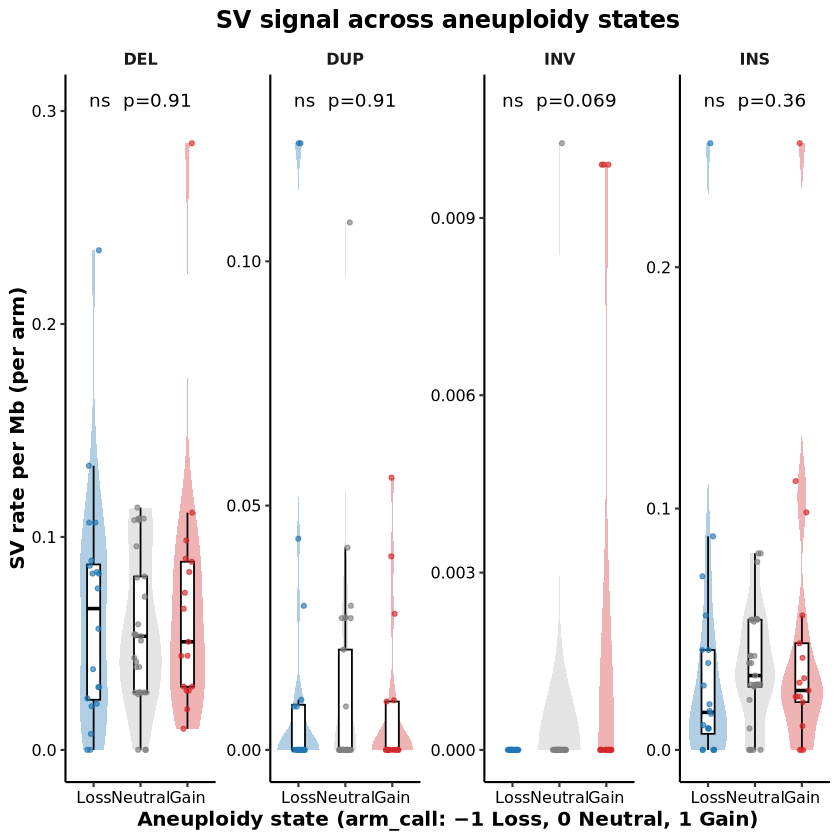

In [45]:
# --- PLOT 1: SV signal vs aneuploidy state (arm_call) ---
set.seed(1)
p1 <- sv_long %>%
  filter(!is.na(aneu_state), is.finite(sv_value)) %>%
  ggplot(aes(x = aneu_state, y = sv_value, fill = aneu_state)) +
  geom_violin(width = 0.9, trim = TRUE, alpha = 0.35, color = NA) +
  geom_boxplot(width = 0.28, outlier.shape = NA, fill = "white", color = "black", linewidth = 0.5) +
  geom_point(aes(color = aneu_state),
             position = position_jitter(width = 0.14, height = 0),
             size = 1.1, alpha = 0.65) +
  facet_wrap(~ type, nrow = 1, scales = "free_y") +
  geom_text(data = kw_df, aes(x = x_pos, y = y_pos, label = label),
            inherit.aes = FALSE, hjust = 0.5, vjust = 0) +
  scale_fill_manual(values = c(Loss = "#1f77b4", Neutral = "grey70", Gain = "#d62728")) +
  scale_color_manual(values = c(Loss = "#1f77b4", Neutral = "grey50", Gain = "#d62728")) +
  guides(fill = "none", color = "none") +
  labs(
    x = "Aneuploidy state (arm_call: −1 Loss, 0 Neutral, 1 Gain)",
    y = paste(switch(sv_prefix,
                     sv_rate = "SV rate per Mb",
                     sv_count = "SV count",
                     sv_proportion = "SV proportion"), "(per arm)"),
    title = "SV signal across aneuploidy states"
  ) +
  theme_nature(12)
print(p1)


`geom_smooth()` using formula = 'y ~ x'


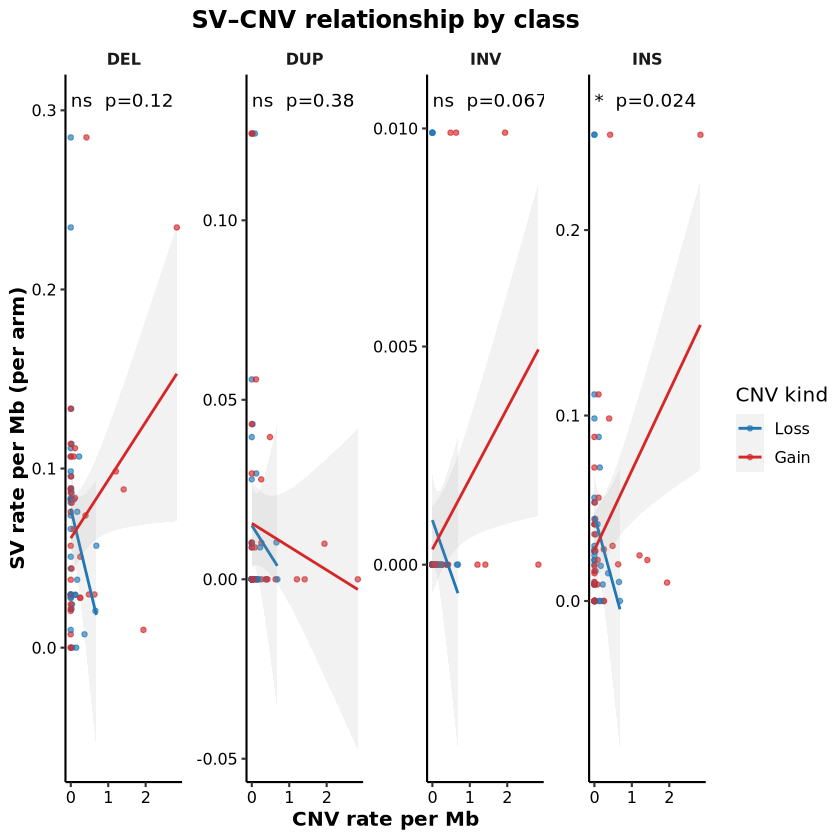

In [46]:
# --- PLOT 2: CNV (Gain/Loss) vs SV signal ---
p2 <- cnv_sv_long %>%
  filter(is.finite(cnv_value), is.finite(sv_value)) %>%
  ggplot(aes(x = cnv_value, y = sv_value, color = cnv_kind)) +
  geom_point(size = 1.2, alpha = 0.65) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 0.8, alpha = 0.12) +
  facet_wrap(~ type, nrow = 1, scales = "free") +
  scale_color_manual(values = c(Loss = "#1f77b4", Gain = "#d62728"), drop = FALSE) +
  geom_text(data = lm_df, aes(x = x_pos, y = y_pos, label = label),
            inherit.aes = FALSE, hjust = 0, vjust = 0) +
  labs(
    x = if (cnv_metric == "cnv_rate_per_mb") "CNV rate per Mb" else "CNV proportion per Mb",
    y = paste(switch(sv_prefix,
                     sv_rate = "SV rate per Mb",
                     sv_count = "SV count",
                     sv_proportion = "SV proportion"), "(per arm)"),
    color = "CNV kind",
    title = "SV–CNV relationship by class"
  ) +
  theme_nature(12)
print(p2)


`geom_smooth()` using formula = 'y ~ x'


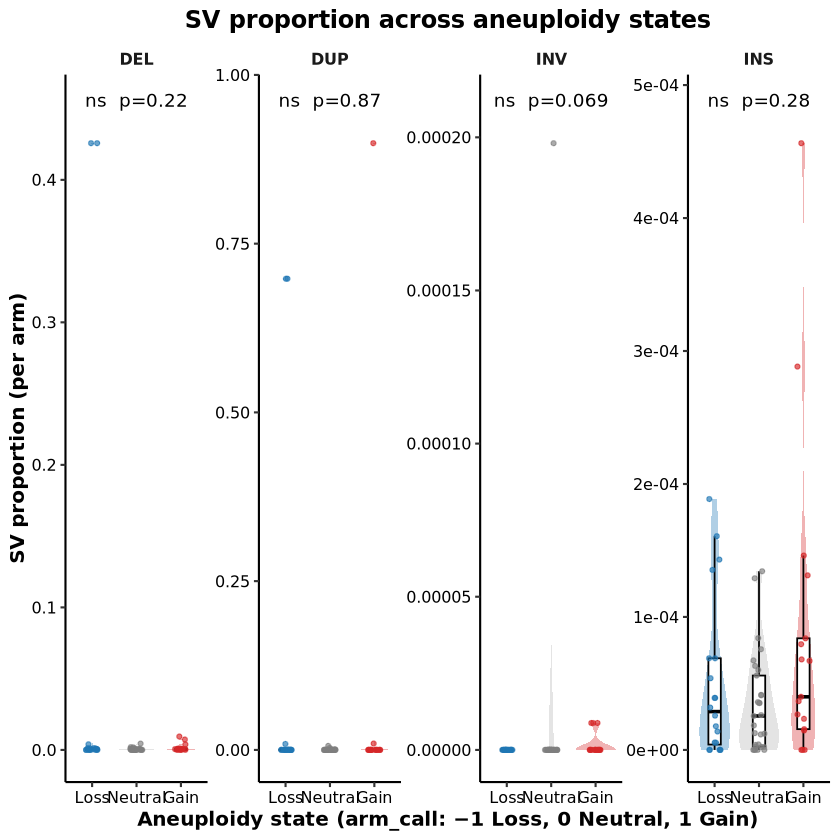

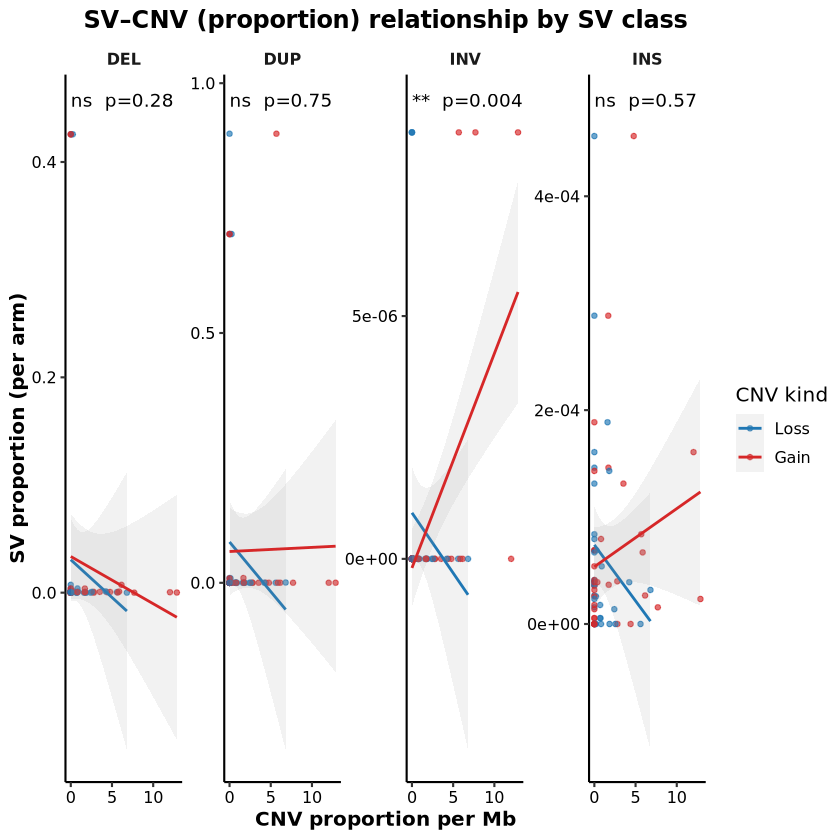

In [47]:
# --- helpers (safe to re-run) ---
p_stars_vec <- function(p){
  out <- rep("ns", length(p))
  out[!is.na(p) & p < 0.05]  <- "*"
  out[!is.na(p) & p < 1e-2]  <- "**"
  out[!is.na(p) & p < 1e-3]  <- "***"
  out[!is.na(p) & p < 1e-4]  <- "****"
  out
}
fmt_p_vec <- function(p){
  out <- rep("p=NA", length(p)); ok <- !is.na(p)
  out[ok & p >= 1e-3] <- paste0("p=", signif(p[ok & p >= 1e-3], 2))
  out[ok & p <  1e-3] <- paste0("p=", formatC(p[ok & p <  1e-3], format="e", digits=2))
  out
}
theme_nature <- function(base_size = 12){
  ggplot2::theme_classic(base_size = base_size) +
    ggplot2::theme(
      axis.title = element_text(face="bold"),
      axis.text  = element_text(color="black"),
      axis.line  = element_line(linewidth = 0.6),
      axis.ticks = element_line(linewidth = 0.6),
      strip.background = element_blank(),
      strip.text = element_text(face="bold"),
      plot.title = element_text(hjust=0.5, face="bold")
    )
}

# --- force proportion metrics ---
sv_prefix   <- "sv_proportion"
cnv_metric  <- "cnv_proportion_per_mb"

stopifnot(any(grepl("^sv_proportion_", names(arm_level))))
stopifnot(any(grepl("^cnv_proportion_per_mb_", names(arm_level))))

# ==========================================================
# PLOT 1 — SV proportion vs aneuploidy state (arm_call)
# ==========================================================
sv_long <- arm_level %>%
  dplyr::select(Sample_ID, region, aneu_state,
                dplyr::matches("^sv_proportion_(DEL|DUP|INV|INS)$")) %>%
  tidyr::pivot_longer(cols = dplyr::matches("^sv_proportion_"),
                      names_to = "sv_type", values_to = "sv_value") %>%
  dplyr::mutate(type = factor(sub("^sv_proportion_", "", sv_type),
                              levels = c("DEL","DUP","INV","INS")))

kw_df <- sv_long %>%
  dplyr::filter(is.finite(sv_value), !is.na(aneu_state)) %>%
  dplyr::group_by(type) %>%
  dplyr::summarise(
    p_kw = tryCatch({
      if (length(unique(aneu_state)) >= 2 && sum(is.finite(sv_value)) >= 3)
        kruskal.test(sv_value ~ aneu_state)$p.value else NA_real_
    }, error = function(e) NA_real_),
    y_pos = suppressWarnings(max(sv_value, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    y_pos = ifelse(is.finite(y_pos), y_pos, 0) * 1.06,
    x_pos = 2,
    label = paste0(p_stars_vec(p_kw), "  ", fmt_p_vec(p_kw))
  )

set.seed(1)
p1 <- sv_long %>%
  dplyr::filter(!is.na(aneu_state), is.finite(sv_value)) %>%
  ggplot2::ggplot(aes(x = aneu_state, y = sv_value, fill = aneu_state)) +
  geom_violin(width = 0.9, trim = TRUE, alpha = 0.35, color = NA) +
  geom_boxplot(width = 0.28, outlier.shape = NA, fill = "white", color = "black", linewidth = 0.5) +
  geom_point(aes(color = aneu_state),
             position = position_jitter(width = 0.14, height = 0),
             size = 1.1, alpha = 0.65) +
  facet_wrap(~ type, nrow = 1, scales = "free_y") +
  geom_text(data = kw_df, aes(x = x_pos, y = y_pos, label = label),
            inherit.aes = FALSE, hjust = 0.5, vjust = 0) +
  scale_fill_manual(values = c(Loss = "#1f77b4", Neutral = "grey70", Gain = "#d62728")) +
  scale_color_manual(values = c(Loss = "#1f77b4", Neutral = "grey50", Gain = "#d62728")) +
  guides(fill = "none", color = "none") +
  labs(
    x = "Aneuploidy state (arm_call: −1 Loss, 0 Neutral, 1 Gain)",
    y = "SV proportion (per arm)",
    title = "SV proportion across aneuploidy states"
  ) +
  theme_nature(12)
print(p1)

# ==========================================================
# PLOT 2 — CNV proportion per Mb vs SV proportion
# ==========================================================
cnv_sv_long <- arm_level %>%
  dplyr::select(Sample_ID, region,
                dplyr::matches("^cnv_proportion_per_mb_(Gain|Loss)$"),
                dplyr::matches("^sv_proportion_(DEL|DUP|INV|INS)$")) %>%
  tidyr::pivot_longer(cols = dplyr::matches("^sv_proportion_"),
                      names_to = "sv_type", values_to = "sv_value") %>%
  dplyr::mutate(type = factor(sub("^sv_proportion_", "", sv_type),
                              levels = c("DEL","DUP","INV","INS"))) %>%
  tidyr::pivot_longer(cols = dplyr::matches("^cnv_proportion_per_mb_(Gain|Loss)$"),
                      names_to = "cnv_kind", values_to = "cnv_value") %>%
  dplyr::mutate(cnv_kind = ifelse(grepl("Gain$", cnv_kind), "Gain", "Loss"),
                cnv_kind = factor(cnv_kind, levels = c("Loss","Gain")))

lm_df <- cnv_sv_long %>%
  dplyr::filter(is.finite(cnv_value), is.finite(sv_value)) %>%
  dplyr::group_by(type) %>%
  dplyr::summarise(
    p_lm = tryCatch({
      fit <- lm(sv_value ~ cnv_value + cnv_kind)
      co <- summary(fit)$coefficients
      if ("cnv_value" %in% rownames(co)) co["cnv_value","Pr(>|t|)"] else NA_real_
    }, error = function(e) NA_real_),
    x_pos = suppressWarnings(min(cnv_value, na.rm = TRUE)),
    y_pos = suppressWarnings(max(sv_value,  na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    x_pos = ifelse(is.finite(x_pos), x_pos, 0),
    y_pos = ifelse(is.finite(y_pos), y_pos, 0) * 1.06,
    label = paste0(p_stars_vec(p_lm), "  ", fmt_p_vec(p_lm))
  )

p2 <- cnv_sv_long %>%
  dplyr::filter(is.finite(cnv_value), is.finite(sv_value)) %>%
  ggplot2::ggplot(aes(x = cnv_value, y = sv_value, color = cnv_kind)) +
  geom_point(size = 1.2, alpha = 0.65) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 0.8, alpha = 0.12) +
  facet_wrap(~ type, nrow = 1, scales = "free") +
  scale_color_manual(values = c(Loss = "#1f77b4", Gain = "#d62728"), drop = FALSE) +
  geom_text(data = lm_df, aes(x = x_pos, y = y_pos, label = label),
            inherit.aes = FALSE, hjust = 0, vjust = 0) +
  labs(
    x = "CNV proportion per Mb",
    y = "SV proportion (per arm)",
    color = "CNV kind",
    title = "SV–CNV (proportion) relationship by SV class"
  ) +
  theme_nature(12)
print(p2)
